In [43]:
# Manipulación de datos
import pandas as pd
import numpy as np
import collections

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

# Keras y TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional,
    BatchNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
import tensorflow as tf



### **Cargar Datos**

In [44]:
# 1. Ruta local donde guardaste el CSV preprocesado
ruta_csv = r"C:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\data\processed\df_preprocesado_LSTM_binario.csv"

# 2. Cargar el DataFrame
df = pd.read_csv(ruta_csv, parse_dates=['FECHA_CIERRE'])

### **Preprocesamiento**

In [45]:
# Convertir booleanos a enteros
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Parámetros
timesteps = 10
target_col = 'ETIQUETA_MORA'

# Columnas numéricas
feature_cols = df.select_dtypes(include=[np.number]).columns.difference([target_col, 'NUMERO DE LA COLOCACION'])

# Escalado de características
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])

# Ordenar por ID de crédito y fecha
df_scaled = df_scaled.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

### **Generación de secuencias**

In [46]:
X_sequences, y_targets, sequence_ids = [], [], []

for _, group in df_scaled.groupby('NUMERO DE LA COLOCACION'):
    group = group.reset_index(drop=True)
    for i in range(len(group) - timesteps):
        X_seq = group.loc[i:i+timesteps-1, feature_cols].values
        y_val = group.loc[i+timesteps, target_col]
        if not np.isnan(X_seq).any() and not pd.isna(y_val):
            X_sequences.append(X_seq)
            y_targets.append(y_val)
            sequence_ids.append(group['NUMERO DE LA COLOCACION'].iloc[0])

X_lstm = np.array(X_sequences)
y_lstm = np.array(y_targets)
sequence_ids = np.array(sequence_ids)

print(f"Secuencias generadas: {X_lstm.shape}, Etiquetas: {y_lstm.shape}")


Secuencias generadas: (8150, 10, 62), Etiquetas: (8150,)


### **División sin fuga de datos y codificación**

In [47]:
unique_ids = np.unique(sequence_ids)
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

train_mask = np.isin(sequence_ids, train_ids)
test_mask = np.isin(sequence_ids, test_ids)

X_train, X_test = X_lstm[train_mask], X_lstm[test_mask]
y_train_raw, y_test_raw = y_lstm[train_mask], y_lstm[test_mask]

# One-hot encoding
y_train = to_categorical(y_train_raw, num_classes=2)
y_test = to_categorical(y_test_raw, num_classes=2)

# Pesos alpha para focal loss
class_weights = compute_class_weight('balanced', classes=np.unique(y_lstm), y=y_lstm)
alpha_weights = (class_weights / np.sum(class_weights)).tolist()
print("Pesos alpha:", alpha_weights)


Pesos alpha: [0.3911656441717791, 0.6088343558282209]


### **Definición de focal loss personalizada**

In [48]:
def focal_loss(gamma=2., alpha=None):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        if alpha is not None:
            alpha_tensor = tf.convert_to_tensor(alpha, dtype=tf.float32)
            cross_entropy *= alpha_tensor
        weight = K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.mean(K.sum(loss, axis=1))
    return loss




### **Definición del modelo**

In [49]:
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(GlobalAveragePooling1D())
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam',
              loss=focal_loss(gamma=2., alpha=alpha_weights),
              metrics=['accuracy'])



c:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### **Entrenamiento**

In [50]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,  # puedes probar 64 o 128
    validation_split=0.2,
    callbacks=[early_stop, lr_reducer]
)



Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7731 - loss: 0.3632 - val_accuracy: 0.9262 - val_loss: 0.2035 - learning_rate: 0.0010
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8963 - loss: 0.1964 - val_accuracy: 0.9362 - val_loss: 0.1493 - learning_rate: 0.0010
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9052 - loss: 0.1429 - val_accuracy: 0.9439 - val_loss: 0.1125 - learning_rate: 0.0010
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9078 - loss: 0.1097 - val_accuracy: 0.9431 - val_loss: 0.0883 - learning_rate: 0.0010
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9175 - loss: 0.0885 - val_accuracy: 0.9262 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9228 - loss: 0.0721 - val_accuracy: 0.9301 - val_loss: 0.0596 - learning_rate: 0.0010
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9221 - loss: 

### **Evaluación y predicción con ajuste de umbral**

In [51]:
loss, acc = model.evaluate(X_test, y_test)
print(f"✅ Accuracy en test: {acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs[:, 1] >= 0.4).astype(int)
y_true = np.argmax(y_test, axis=1)



52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9372 - loss: 0.0250
✅ Accuracy en test: 0.9362
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


### **Reporte de métricas y visualización**

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

   0: Al día       0.97      0.82      0.89      1005
  1: En mora       0.77      0.96      0.86       640

    accuracy                           0.87      1645
   macro avg       0.87      0.89      0.87      1645
weighted avg       0.89      0.87      0.88      1645



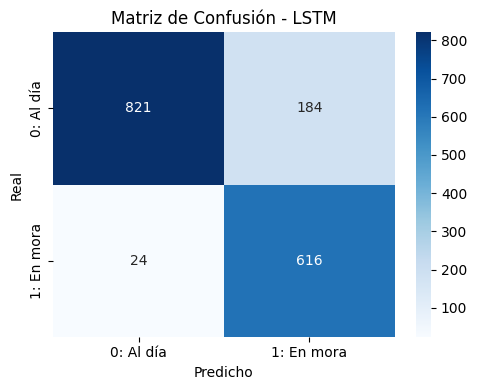

In [52]:
print("📋 Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=["0: Al día", "1: En mora"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0: Al día", "1: En mora"],
            yticklabels=["0: Al día", "1: En mora"])
plt.title("Matriz de Confusión - LSTM")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()



### **Curvas de entrenamiento**

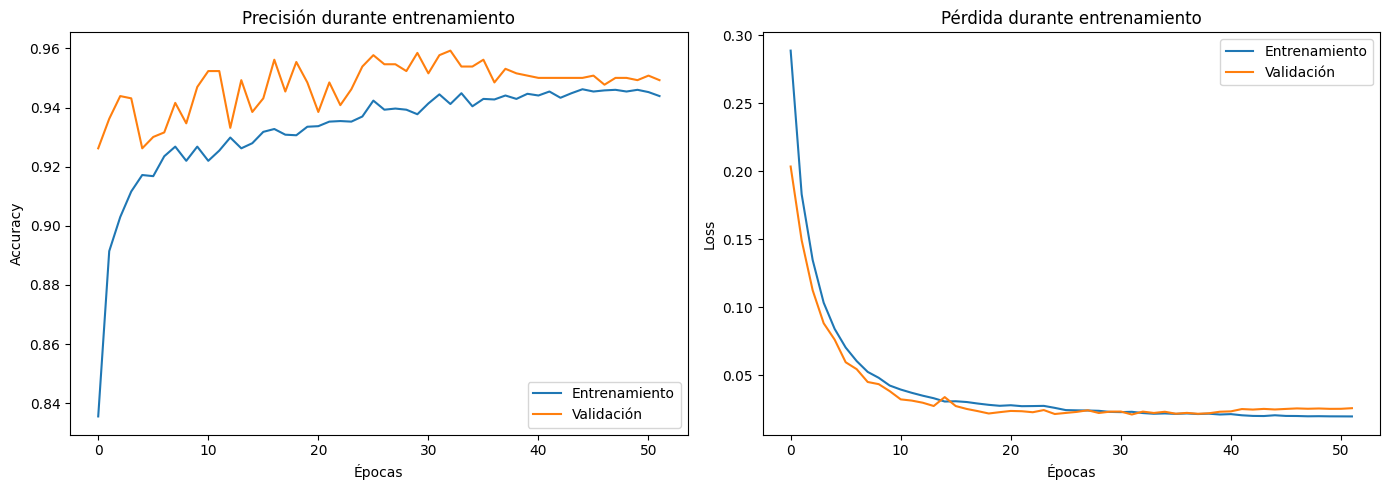

In [53]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
